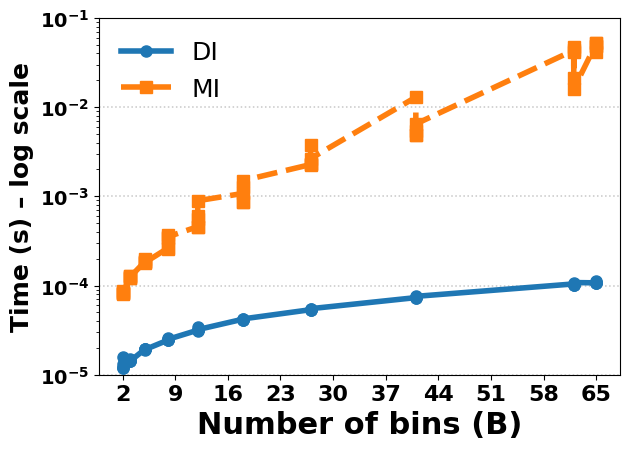

[np.int64(2), 710, np.int64(65)]


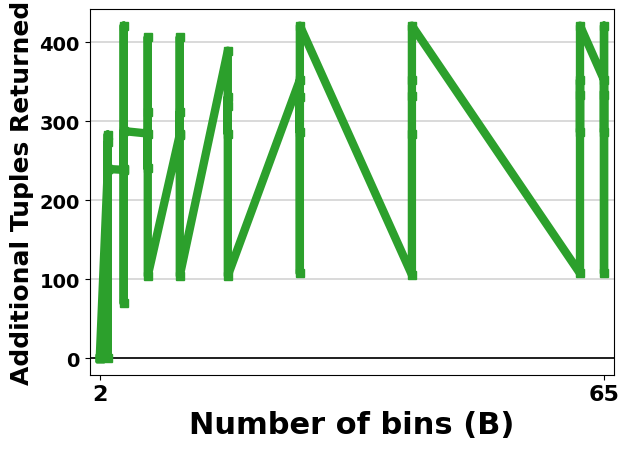

In [47]:
import argparse, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_binned(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    b = df[df["kind"].astype(str).str.lower() == "binned"].copy()
    if b.empty:
        raise ValueError("No 'binned' rows found in CSV.")

    num_cols = [
        "bins_count",
        "time_alg1_s", "time_alg1_first_s",
        "time_alg2_s", "time_alg4_s",
        "utility_babble", "utility_base", "utility_star",
        "q_base_groups", "q_star_groups",
    ]
    for c in num_cols:
        if c in b.columns:
            b[c] = pd.to_numeric(b[c], errors="coerce")

    # CD time column selection
    if "time_alg1_s" in b.columns and b["time_alg1_s"].notna().any():
        b["time_alg1_plot"] = b["time_alg1_s"].fillna(0.0)
    elif "time_alg1_first_s" in b.columns and b["time_alg1_first_s"].notna().any():
        b["time_alg1_plot"] = b["time_alg1_first_s"].fillna(0.0)
    else:
        b["time_alg1_plot"] = 0.0

    # MI time = Alg2 + Alg4
    b["time_alg24_s"] = b["time_alg2_s"].fillna(0.0) + b["time_alg4_s"].fillna(0.0)

    # Gains vs babble
    b["gain_base"] = b["utility_base"] - b["utility_babble"]
    b["gain_star"] = b["utility_star"] - b["utility_babble"]

    return b.dropna(subset=["bins_count"]).sort_values("bins_count")

def _safe_log(arr):
    arr = np.asarray(arr, dtype=float)
    if np.any(arr <= 0):
        pos = arr[arr > 0]
        eps = (pos.min()*1e-3) if pos.size else 1e-9
        arr = np.where(arr <= 0, eps, arr)
    return arr

def _sparse_ticks(xs, max_ticks=10):
    """Return a sparse, monotone set of ticks: always include first & last."""
    xs = np.asarray(xs, dtype=int)
    xmin, xmax = xs.min(), xs.max()
    if len(xs) <= max_ticks:
        return xs
    ticks= [xmin, 710,  xmax]


    return ticks

def _apply_style():
    plt.rcdefaults()
    plt.style.use("default")
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "grid.linewidth": 1.1,
        "grid.alpha": 0.6,
        "grid.linestyle": "-",
    })

def plot_time_vs_bins_refined(b: pd.DataFrame, out_png: str, dataset="dataset", max_xticks=10, smooth=False):
    # _apply_style() # Assuming this is defined in your environment
    xs = b["bins_count"].to_numpy(int)

    # Raw data
    y_cd_raw = b["time_alg1_plot"].to_numpy(float)
    y_mi_raw = b["time_alg24_s"].to_numpy(float)

    # Optional: Smoothing filter for low-time/high-noise datasets
    if smooth and len(xs) > 5:
        window = 3
        y_cd = pd.Series(y_cd_raw).rolling(window=window, min_periods=1, center=True).mean().to_numpy()
        y_mi = pd.Series(y_mi_raw).rolling(window=window, min_periods=1, center=True).mean().to_numpy()
    else:
        y_cd = y_cd_raw
        y_mi = y_mi_raw

    fig, ax = plt.subplots(figsize=(6.4, 4.6), facecolor="white")

    # Plotting
    ax.plot(xs, y_cd, marker="o", linewidth=4, label="DI", zorder=3, markersize=8)
    ax.plot(xs, y_mi, marker="s", linewidth=4, linestyle="--", label="MI", zorder=3, markersize=8)

    ax.set_xlabel("Number of bins (B)", fontweight="bold", fontsize=22)
    ax.set_ylabel("Time (s) – log scale", fontweight="bold", fontsize=18)

    # Scale and Limits
    ax.set_yscale("log")

    # FIX: Use a global consistent range or a padded range to avoid magnifying noise
    y_all = np.concatenate([y_cd, y_mi])
    lo = 10 ** np.floor(np.log10(y_all.min()))
    hi = 10 ** np.ceil(np.log10(y_all.max()))

    # Ensure at least 3 orders of magnitude to compress visual jitter
    if hi / lo < 1000:
        lo /= 10.0
        hi *= 10.0

    ax.set_ylim(lo, hi)

    # Ticks and Labels
    # ticks = _sparse_ticks(xs, max_xticks=max_xticks) # Assuming this is defined
    ticks = np.linspace(xs.min(), xs.max(), max_xticks, dtype=int)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontweight="bold", fontsize=16)

    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontsize(14)

    ax.grid(True, which="major", axis="y", linestyle=':', alpha=0.7)
    ax.legend(loc="upper left", fontsize=18, frameon=False)

    fig.tight_layout()
    plt.show()

def plot_gain_vs_bins(b: pd.DataFrame, out_png: str, max_xticks=10):
    _apply_style()
    xs = b["bins_count"].to_numpy(int)
    # g_base = b["gain_base"].to_numpy(float)
    g_star = b["gain_star"].to_numpy(float)

    fig, ax = plt.subplots(figsize=(6.4, 4.6), facecolor="white")
    # ax.plot(xs, g_base, marker="o", linewidth=6, label="q_base − babble", zorder=3)
    ax.plot(xs, g_star, marker="s", linewidth=6, linestyle="-", label="q★ − babble", zorder=3, color="tab:green")

    ax.set_xlabel("Number of bins (B)", fontweight="bold", fontsize=22)
    ax.set_ylabel("Additional Tuples Returned", fontweight="bold", fontsize=18)
    ax.axhline(0.0, color="black", linewidth=1.2)

    #sparse x-ticks
    ticks = _sparse_ticks(xs)
    print(ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontweight="bold", fontsize=16)

    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold"); lbl.set_fontsize(14)

    ax.grid(True, which="major", axis="y")
    #ax.legend(loc="upper left", fontsize=16, frameon=False)
    ax.margins(x=0.02)
    fig.tight_layout()

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    plt.show()
    #fig.savefig(out_png, bbox_inches="tight", dpi=200)
    plt.close(fig)

b = load_binned("../tables/results_age_compas.csv")
plot_time_vs_bins(b, "time_vs_bins_compas.png", dataset="Amazon Price")
plot_gain_vs_bins(b, "utility_vs_bin_compas.png")


In [25]:
def plot_time_vs_attributes(b: pd.DataFrame, out_png: str, dataset="dataset", max_xticks=10):
    _apply_style()
    xs = b["bins_count"].to_numpy(int)
    y_cd = _safe_log(b["time_alg1_plot"].to_numpy(float))
    y_mi = _safe_log(b["time_alg24_s"].to_numpy(float))
    y_all = np.concatenate([y_cd, y_mi])

    fig, ax = plt.subplots(figsize=(6.4, 4.6), facecolor="white")
    ax.plot(xs, y_cd, marker="o", linewidth=6, label="DI", zorder=3)
    ax.plot(xs, y_mi, marker="s", linewidth=6, linestyle="--", label="MI", zorder=3)

    ax.set_xlabel("Number of attributes", fontweight="bold", fontsize=25)
    ax.set_ylabel("Time (s) – log scale", fontweight="bold", fontsize=25)

    # log y-range
    lo = 10 ** np.floor(np.log10(y_all.min()))
    hi = 10 ** np.ceil(np.log10(y_all.max()))
    if lo == hi:
        lo /= 10.0; hi *= 10.0
    ax.set_yscale("log"); ax.set_ylim(lo, hi)

    # sparse x-ticks: start, end, few in middle
    ticks = _sparse_ticks(xs, max_ticks=max_xticks)
    print("Ticks:", ticks)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontweight="bold", fontsize=16)

    for lbl in ax.get_yticklabels():
        lbl.set_fontweight("bold"); lbl.set_fontsize(14)

    ax.grid(True, which="major", axis="y")
    ax.legend(loc="upper left", fontsize=18, frameon=False)
    ax.margins(x=0.02)
    fig.tight_layout()

    os.makedirs(os.path.dirname(out_png) or ".", exist_ok=True)
    fig.savefig(out_png, bbox_inches="tight", dpi=200)
    plt.show()
    plt.close(fig)

Ticks: [1 2 3]


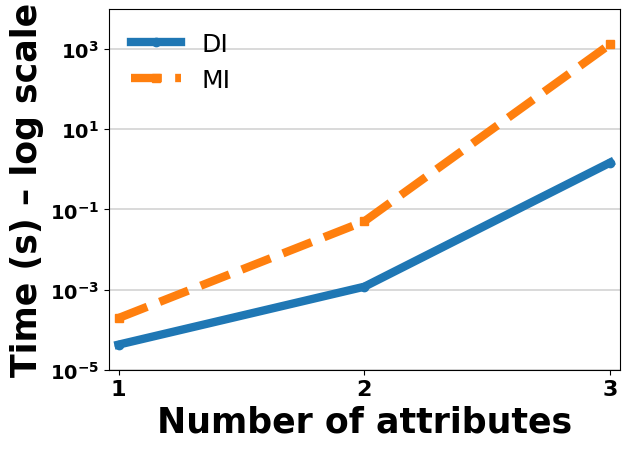

In [30]:
dataset="amazon"
import pandas as pd
import os
PATH="../tables/"
df=pd.read_csv(os.path.join(PATH,f"{dataset}_products_3_time_vs_num_attrs.csv"))
df.head()

xs=df["k_attrs"].tolist()
ys_alg1=df["time_alg1_first_s"].tolist()
ys_alg24=df["time_alg24_s"].tolist()
#make milisecond second

#keep on 3 values in ys_alg24, xs, ys_alg1
ys_alg1=ys_alg1[:3]
ys_alg24=ys_alg24[:3]
xs=xs[:3]
#make dataframe for plotting
df_plot=pd.DataFrame({"bins_count":xs,"time_alg1_plot":ys_alg1,"time_alg24_s":ys_alg24})

plot_time_vs_attributes(df_plot, f"{dataset}_time_vs_num_attrs.png")